**Author** : Lucile Lapray

**Date** : May 2025

The purpose of this notebook is to extract movie data from the IMDb website.
The data is scraped from the IMDb website by Pavan Kalyan Reddy Thota. It is saved in JSON format.

Here, we extract the data we're interested in from this database and save it as a csv file.
With the aim of subsequently using this data as a prompt iteration on an LLM, we manipulate the data and reduce the dataset to only the data relevant to our future analysis.

Source : https://www.kaggle.com/datasets/pavan4kalyan/imdb-dataset-of-600k-international-movies?select=international-movies-json 

## 1. Library import

In [3]:
# Data extraction
import os
import json
import csv
# Data manipulation
import pandas as pd
import numpy as np
import re
# Data description
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(context = 'notebook', style='darkgrid', palette='viridis', font='serif')

## 2. Data extraction

In [2]:
def flatten_movie(movie):
    # Convert genre list to string
    genre_str = ','.join(movie.get('genre', []))
    
    # Keep only specified columns
    return {
        'ImdbId': movie.get('ImdbId', ''),
        '_id': movie.get('_id', ''),
        'name': movie.get('name', ''),
        'year': movie.get('year', ''),
        'runtime': movie.get('runtime', ''),
        'genre': genre_str,
        'summary_text': movie.get('summary_text', '')
    }

In [3]:
def main():
    input_dir = 'international-movies-json'  # Update this path
    output_file = '1-movies.csv'
    
    all_movies = []

    # Process each JSON file
    for filename in os.listdir(input_dir):
        if filename.endswith('.json'):
            filepath = os.path.join(input_dir, filename)
            try:
                with open(filepath, 'r', encoding='utf-8') as file:
                    movies = json.load(file)
                    for movie in movies:
                        all_movies.append(flatten_movie(movie))
            except Exception as e:
                print(f"Error processing {filename}: {e}")
                continue

    # Write to single CSV
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        if all_movies:
            writer = csv.DictWriter(csvfile, fieldnames=all_movies[0].keys())
            writer.writeheader()
            writer.writerows(all_movies)
            print(f"Created {output_file} with {len(all_movies)} rows.")
        else:
            print("No data found to export.")


In [4]:
if __name__ == '__main__':
    main()

Created 1-movies.csv with 633719 rows.


## 3. Data manipulation

We reduce the dataset to only the lines that will indeed be used in the analysis in order to reduce the number of requests of LLM.

We will only use movies that have a synopsis since that will be the text given to the LLM. Moreover, we keep lines where the year of the movie exists since this will later be used in our analysis.

In [ ]:
# Read the CSV file
df_movies = pd.read_csv('1-movies.csv')

# 1. Remove rows with "Add a Plot" in summary_text
df_1st_clean = df_movies[df_movies['summary_text'] != 'Add a Plot']

# 2. Clean year column using regex to extract only the 4-digit year
df_1st_clean['year'] = df_1st_clean['year'].str.extract(r'(\d{4})', expand=False)
df_1st_clean = df_1st_clean.dropna(subset=['year'])

df_1st_clean.head(4)

,ImdbId,_id,name,year,runtime,genre,summary_text
0,tt0144999,tt0144999,"Isaia, horeve",1966,72 min,Comedy,A spirited wife tries to keep her husband's ma...
3,tt0142383,tt0142383,Le huitième jour,1960,78 min,Drama,"Françoise, a thirty-year-old single typist liv..."
4,tt0142346,tt0142346,Half Way to Hell,1960,75 min,"Action, Romance, Western","Prior to the revolution, Senorita Maria San Ca..."
6,tt0141736,tt0141736,Podnyataya tselina,1960,278 min,Drama,"Historical drama, based on the novel by Mikhai..."


In [ ]:
# Save the cleaned data to a new CSV
df_1st_clean.to_csv('2-cleaned_movies.csv', index=False)
print("Cleaning complete! Saved as 2-cleaned_movies.csv")

Cleaning complete! Saved as 2-cleaned_movies.csv


## 4. Data reduction

### 4.1. Subject based selection

In [5]:
df = pd.read_csv('2-cleaned_movies.csv')

In [6]:
def check_keywords_series(series, keywords):
    return series.apply(lambda x: any(keyword in x.lower() for keyword in keywords))


df['Prostitute'] = check_keywords_series(df['summary_text'], [
    ' prostitute ', ' prostitute.', ' prostitute,', ' prostitutes ', ' prostitutes.', ' prostitutes,'
])

df['Prostitution'] = check_keywords_series(df['summary_text'], [
    ' prostitution ', ' prostitution.', ' prostitution,'
])

df['Sex Worker'] = check_keywords_series(df['summary_text'], [
    ' sex worker ', ' sex worker.', ' sex worker,', ' sex workers ', ' sex workers.', ' sex workers,'
])

df['Escort'] = check_keywords_series(df['summary_text'], [
    ' escort ', ' escort.', ' escort,', ' escorts ', ' escorts.', ' escorts,'
])

df['Call Girl'] = check_keywords_series(df['summary_text'], [
    ' call girl ', ' call girl.', ' call girl,', ' call girls ', ' call girls.', ' call girls,'
])

df['Brothel'] = check_keywords_series(df['summary_text'], [
    ' brothel ', ' brothel.', ' brothel,', ' brothels ', ' brothels.', ' brothels,'
])

df['Pimp'] = check_keywords_series(df['summary_text'], [
    ' pimp ', ' pimp.', ' pimp,', ' pimps ', ' pimps.', ' pimps,'
])

df['Streetwalker'] = check_keywords_series(df['summary_text'], [
    ' streetwalker ', ' streetwalker.', ' streetwalker,', ' streetwalkers ', ' streetwalkers.', ' streetwalkers,'
])

df['Red Light District'] = check_keywords_series(df['summary_text'], [
    ' red light district ', ' red light district.', ' red light district,', ' red light districts ', ' red light districts.', ' red light districts,'
])

df['Sex Trade'] = check_keywords_series(df['summary_text'], [
    ' sex trade ', ' sex trade.', ' sex trade,'
])

df['Sex Trafficking'] = check_keywords_series(df['summary_text'], [
    ' sex trafficking ', ' sex trafficking.', ' sex trafficking,'
])

df['Libertine'] = check_keywords_series(df['summary_text'], [
    ' libertine ', ' libertine.', ' libertine,'
])

df['Prostitution Ring'] = check_keywords_series(df['summary_text'], [
    ' prostitution ring ', ' prostitution ring.', ' prostitution ring,', ' prostitution rings ', ' prostitution rings.', ' prostitution rings,'
])

df['Sex Services'] = check_keywords_series(df['summary_text'], [
    ' sex services ', ' sex services.', ' sex services,'
])

df['Sexual Exploitation'] = check_keywords_series(df['summary_text'], [
    ' sexual exploitation ', ' sexual exploitation.', ' sexual exploitation,'
])

df['Commercial Sex'] = check_keywords_series(df['summary_text'], [
    ' commercial sex ', ' commercial sex.', ' commercial sex,'
])

df['Hooker'] = check_keywords_series(df['summary_text'], [
    ' hooker ', ' hooker.', ' hooker,', ' hookers ', ' hookers.', ' hookers,'
])


In [7]:
columns_to_check = ['Prostitute', 'Prostitution',
    'Sex Worker', 'Escort', 'Call Girl',
    'Brothel', 'Pimp', 'Streetwalker',
    'Red Light District', 'Sex Trade', 'Sex Trafficking', 'Libertine',
    'Prostitution Ring', 'Sex Services', 'Sexual Exploitation',
    'Commercial Sex', 'Hooker']

mask = df[columns_to_check].any(axis=1)
filtered_df = df[mask].copy()
filtered_df.head(4)

,ImdbId,_id,name,year,runtime,genre,summary_text,Prostitute,Prostitution,Sex Worker,...,Streetwalker,Red Light District,Sex Trade,Sex Trafficking,Libertine,Prostitution Ring,Sex Services,Sexual Exploitation,Commercial Sex,Hooker
28,tt0117594,tt0117594,Segurista,1996,111 min,Drama,"In the daytime, Karen is an insurance saleswom...",False,False,False,...,False,False,False,False,False,False,False,False,False,False
30,tt0117414,tt0117414,Qi yi lu cheng: Zhen xin ai sheng ming,1996,100 min,"Comedy, Drama",Souad is a prostitute whose best friend is Ken...,True,False,False,...,False,False,False,False,False,False,False,False,False,False
87,tt0083981,tt0083981,Fury in the Tropics,1986,85 min,"Crime, Adult",Two prostitutes in a small corrupt South Ameri...,True,False,False,...,False,False,False,False,False,False,False,False,False,False
160,tt0041646,tt0041646,Maya,1949,78 min,Drama,"Based on a venerable Legend of the Sea, the st...",True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Save the cleaned data to a new CSV
filtered_df.to_csv('3-prostitution_movies.csv', index=False)
print("Cleaning complete! Saved as 3-prostitution_movies.csv")

Cleaning complete! Saved as 3-prostitution_movies.csv


### 4.2. Random subset creation

With the bag of words method, we found around 3000 movies directly dealing with prostitution related topics. For the purpose of LLM annotation, this number is still too big. We choose to reduce it to 800 movies.

Knowing we aim to do an analysis of movies over time, we decide to constrain our random selection to a uniformly distributed (over time) set of movies. This constraint is not strict as there are less movies early on as there are later on.

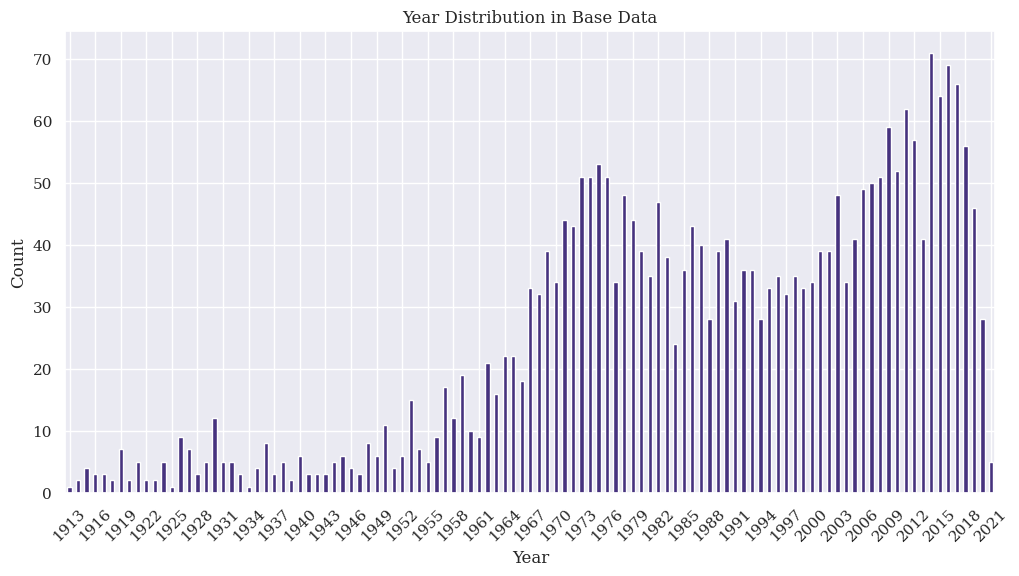

In [8]:
plt.figure(figsize=(12, 6))
filtered_df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Year Distribution in Base Data')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xticks(range(0, 110, 3), [i for i in range(1913, 2022, 3)])
plt.show()

In [9]:
# Sample a subset for the analysis
# 1. Get year distribution counts
year_counts = filtered_df['year'].value_counts().reset_index()
year_counts.columns = ['year', 'total_count']

# 2. Calculate target samples per year (uniform distribution)
num_years = len(year_counts)
target_per_year = np.ceil(800 / num_years).astype(int)

# 3. Create sampling frame
sampled_data = pd.DataFrame()

for year in year_counts['year']:
    year_subset = filtered_df[filtered_df['year'] == year]
    
    # Calculate how many to sample from this year
    n_samples = min(target_per_year, len(year_subset))
    
    # Random sample without replacement
    sampled_year = year_subset.sample(n=n_samples, random_state=42)
    
    sampled_data = pd.concat([sampled_data, sampled_year])

# 4. If total < 800, fill remaining slots randomly
remaining = 800 - len(sampled_data)
if remaining > 0:
    extra_samples = filtered_df[~filtered_df.index.isin(sampled_data.index)].sample(n=remaining, random_state=42)
    sampled_data = pd.concat([sampled_data, extra_samples])


In [14]:
sampled_data.to_csv('4-prostitution_movies_sample.csv', index=False)

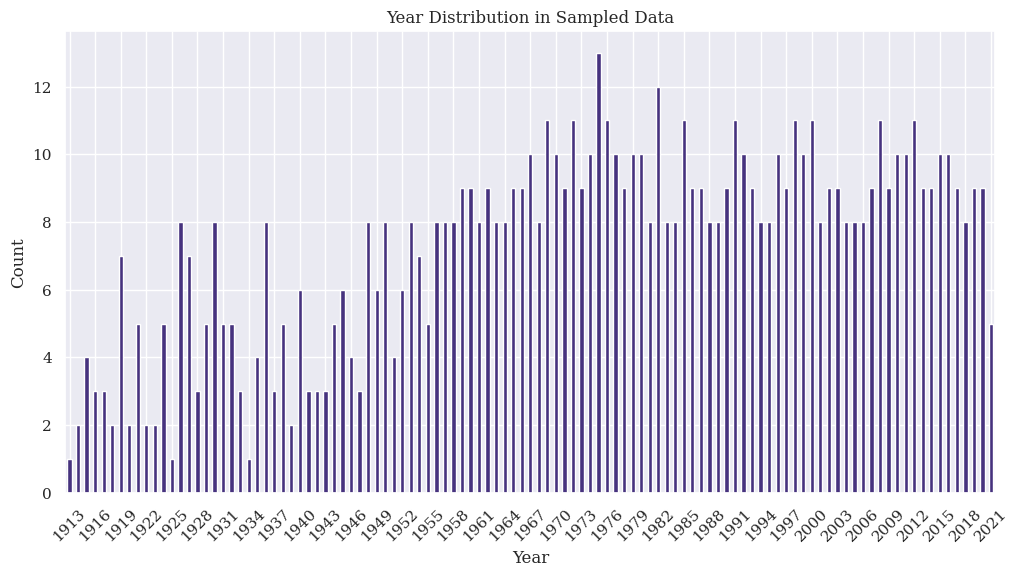

In [10]:
plt.figure(figsize=(12, 6))
sampled_data['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Year Distribution in Sampled Data')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xticks(range(0, 110, 3), [i for i in range(1913, 2022, 3)])
plt.show()

## 5. Data annotation

The two next lists where produced by phi-4 on the Kaggle notebook. Because of some saving issue, we copied these lists in order to use them while solving the issue.

In [16]:
positivity = ["'0.2'", "'-0.7'", "'-0.8'", "-0.8'", "'-0.5'", "'0.2'", "'-0.7'", "'0'", "'-0.2'", "'0.2'", "'0.6'", "'0.5'", "'0.2'", "-0.8'", '-0.8.', "'0'", "'0.2'.", "'-0.3'", "'0.2'", "'-0.5'", "'0.2'", "'-0.3'", "'0.6'", "scale.'", "'0.5'", "'0.3'", "'0'", "'0.2'", "'0.2'", "'-0.8'", "'-0.5'", "'-0.5'", "'-0.5'", "'-1'", "'0.2'", "'0.2'", "'0.6'", '0.2.', "'-0.5'", "'0.2'", "'-0.5'", "'0.3'", "'-0.3'", "'0.2'", "'-0.3'", "'0.2'", "'-0.6'", '-0.6.', '-0.3.', "'-0.5'", "'0.3'", "'0.2'", "'-0.5'", "'-0.5'", "'0.2'", "'-0.5'", "'0.3'", "'-0.9'", "'-0.8'", "'-0.8'", "'-0.5'", "'0.6'", "'-0.5'", "'-0.8'", "'0'", "'-0.8'", "'-0.7'", "'-0.3'", "'0.3'", "'-0.7'", '-0.7.', "'-0.5'", "'0.2'", "'0'", "'0.2'", "'0.4'", "'0.5'", '-0.5', "'0.6'", "'-0.5'", "'0'", "'-0.5'", "'0.2'", "'-0.2'", "'-0.5'", "'0.3'", "'-0.7'", "'-0.7'", '-0.5.', "'-0.3'", "'-1'", "'0.3'", "'0.2'", '-0.8.', "'-0.5'", "-0.5'", "'-0.5'", "'0.2'", "'-0.7'", "'-0.7'", "'0.6'", "'0.3'", "'0.8'", "'-0.8'", "'0.6'", "'-1'", "'-0.7'", "'0.5'", "'-0.6'", "'Negative'", "'0.6'", "'0.5'", "'0.2'", "'0'", "'0.6'", "'0.3'", "'-1'", "'0.2'", "'0'", "'-0.3'", "'-0.5'", "'-0.8'", "'-0.7'", "'0.6'", "'0.3'", "'0.2'", "'-0.6'", "'0.3'", "'-0.5'", "'0.3'", "'-0.5'", "'0.3'", "'0.2'", "'-0.7'", "'0.7'", "'-0.2'", "'-0.7'", "'-0.5'", "'0.2'", "'-0.5'", "'-0.7'", '-0.3', "'-0.7'", "'-0.9'", "'-0.5'", "'0.2'", "'0.6'", "'-0.8'", "'-0.5'", "'-0.5'", "'0.3'", "'-0.3'", "'-0.8'", "'-0.7'", "'-1'", "'-0.5'", "'-0.7'", "'0.2'", "'-0.5'", "'-1'", "'0.5'", "'0.2'", "'0.2'", '-0.5.', "'-0.8'", "'0.5'", "'0.2'", "'0.2'", "'0.6'", "'-0.5'", "'-0.5'", "'0.6'", "'-0.5'", "'0.5'", "'-0.5'", '-0.3.', "'-0.8'", "'-0.8'", "'0.6'", "'-0.5'", "'-0.5'", "'-1'", "'0.7'", "'0.2'", "'-0.7'", "'0'", "'0.3'", "'0.2'", "'0'", "'0.2'", "'0.7'", "'-1'", "-0.6.'", "'-0.5'", "'0.5'", "'-0.5'", "'-0.3'", "'-0.3'", "'-0.5'", "'-0.5'", "'-1'", '-0.5.', "'-0.3'", "'0.2'", "'0.2'", "'-0.7'", "'0.2'", "'0.2'", "'0.5'", "'-0.3'", "'0.5'", "'-0.5'", "'0.7'", "'-0.5'", "'-0.8'", "'0.2'", "'0.5'", "'0.7'", "'0.3'", "'-0.5'", "'-0.8'", "'0.2'", "'0.2'", "'-0.3'", "'-0.5'", "'-0.8'", "'-0.6'", "'0.3'", "'-0.8'", "'-0.3'", "'-0.3'", "'0.2'", "'0.2'", "'0.6'", "'-0.5'", "'0'", "'0.2'", "'0.2'", "'-0.5'", "'0.3'", "'0.2'", "'Negative'", "'0.3'", "'0.8'", "'0.6'", "'0.2'", "'-0.5'", "'-1'", "'0.2'", "'-0.7'", "'-0.3'", "'-0.8'", "'0.3'", "'0.2'", "'-0.7'", "'-0.5'", "'0.2'", "'-0.3'", "'-0.6'", "'-0.7'", "'0.2'", "'-0.8'", "'0.2'", "'0'", "-0.9'", "'0.3'", "'0.7'", "'0.3'", "'0.5'", '-0.5.', "'-0.5'", "'0.6'", "'0.2'", "'0.2'", "'0.2'", '-0.8.', "'0.3'", "'0.3'", "'0.2'", "'0.6'", "'-0.5'", "'0.2'", 'scale.', "'-0.7'", "'-0.7'", "'-0.3'", "'-0.8'", "-0.8'", '-0.6.', "'0.3'", "'-0.7'", "'0.5'", "'0'", "'0.8'", "'-0.8'", "'-0.7'", "'-0.3'", "'-0.3'", "'-0.5'", "'0.6'", "'-0.5'", "'-0.3'", "'-0.3'", "'-0.8'", "'0.1'", "'-0.7'", 'scale.', "'0.3'", "'0.2'", '-0.5', "'0.4'", "'-0.7'", "'-0.5'", "'-0.6'", '-0.8.', "'0.6'", "'0.6'", "'-0.5'", "'-0.7'", "'0'", "'-0.5'", "'0.4'", "'-0.5'", "'0.6'", "'-0.6'", "-0.5.'", "'-0.3'", "'-0.5'", "'-0.5'", "'-1'", "'0.3'", "'-0.3'", "'-0.5'", "'0.2'", "'-0.7'", "'0.3'", "-0.8'", "'0.6'", "'-0.5'", "'0.3'", "'-0.7'", "'0.7'", "'0.2'", "'-0.7'", "'0.6'", "'0.2'", "'0.6'", "'0.2'", "'-0.8'", "'0'", "'0.2'", "'-0.3'", "'0'", "'0.3'", "'0.7'", "'0.2'", "'0.2'", "'0.5'", "'-0.7'", "'0.6'", "'0.2'", "'-0.6'", "'0.2'", "'-0.5'", "'0.3'", "'0.7'", "'-0.2'", '-0.3', "'-0.8'", "'0.6'", "'-0.5'", "'0.5'", "'0.2'", '-0.5', "'-0.8'", "'-0.7'", "'-0.5'", "'-0.5'", "'-0.7'", "'0.2'", "'0.7'", "'-0.7'", "'0.3'", "'-0.5'", "'-0.8'", "'0.7'", "'-0.8'", "'0.2'", "'-0.8'", "'-1'", "'-0.5'", "'0.2'", '-0.2', "'-0.5'", "'-0.7'", "'-0.7'", "'-0.5'", "'0.2'", "'0.5'", "'0.2'", "'0.2'", "'-0.5'", "'-0.8'", "'0.3'", "'0.2'", "'X'", "'0.2'", "-0.3'", '0.5.', "'-0.5'", "'0.2'", "'0.2'", "'0.2'", "'0.2'", "'-0.8'", "'-0.5'", "'-0.6'", "'0.3'", "'-0.5'", "'0'", "'-0.5'", "-0.7.'", "'Negative'", "'-0.5'", "'-0.7'", "'0.2'", "'-0.6'", "'-0.5'", "'-0.3'", "'-0.5'", "'0.3'", "'-0.3'", "'0.2'", "'-0.8'", "'-1'", "'-0.5'", "'-0.7'", "'0.2'", "'-0.7'", "'Negative'", "'-0.3'", "'0.2'", "'-1'", "'0.2'", "'0.1'", "'-0.2'", "'-0.6'", "'-0.3'", "'0.3'", "'-0.5'", 'scale.', "'-0.7'", "'-0.8'", "'0.7'", "'0.2'", "'0.2'", "'-0.8'", "'-0.5'", "'-0.5'", "'0.2'", "'0.5'", "-0.8.'", "'0.8'", "'-0.7'", "'-0.3'", "'-0.5'", "'0.3'", "'-0.5'", "'-0.6'", "'-0.5'", "'0.2'", "'-0.7'", "'0.2'", "'-0.7'", "'0.2'", "'0.6'", "'0.5'", "'0.8'", "'-0.7'", "'0.6'", "'-1'", "'-0.7'", "'0.2'", "'-0.7'", "'-0.7'", "'0.75'", "'0.3'", "'-0.3'", "'-0.8'", "'-0.3'", "'0.8'", "'-0.5'", "'-0.5'", "'-0.8'", "'-0.2'", "'-0.5'", "'0.7'", "'0.3'", "'-0.7'", "'-0.6'", "'-0.8'", "'-0.7'", "'-0.5'", "'0.2'", "'0.3'", "'-0.8'", "'-0.6'", "'0.2'", "'-0.5'", "'0.2'", "'Negative'", "'-0.5'", "'-0.7'", "'-0.7'", "'0.3'", "'-0.6'", "'0.7'", "'0.6'", "'-0.5'", "'-0.5'", "'0.7'", "'0.2'", "'-0.8'", "'-0.5'", "'0.2'", "'-0.5'", "'-0.5'", "'-0.3'", 'scale.', "'0.2'", "'-0.8'", "'0.2'", '-0.7.', "'0.2'", "'0.2'", "'0.2'", "'-0.3'", '-0.3', "'0.2'", "'0.5'", "'-0.7'", "'-0.8'", "'0.3'", "'0.6'", "'0.7'", "'-0.8'", "'-0.7'", "'0.2'", "'-0.8'", "'0.6'", "'-0.8'", "'-0.7'", "'-0.3'", "'0.2'", "'-0.5'", "'-0.7'", "'-0.8'", "'-0.7'", "'Negative'", "'0.2'", "'0.5'", "'-0.7'", "'0.4'", "'-1'", "-0.2'", "'0.3'", "'0.7'", "'0.3'", "'-0.6'", "'0.5'", "'-0.5'", "'0.2'", "'0'", "'0.3'", "'-0.3'", "'0.7'", "'-0.3'", "'0.3'", "'-0.8'", "'-0.3'", "'-0.5'", "'-0.3'", "'-0.7'", "'0.4'", "'-0.5'", "'0.2'", "'-0.5'", "'0.4'", "'-0.5'", "'-1'", "'-0.7'", "'0.7'", "'0.6'", "'-0.7'", "'-0.5'", "'-0.3'", "'0.3'", "'-0.6'", "'-0.3'", "'-0.5'", "'0.2'", "'-0.2'", "'-0.5'", "'0.3'", "'-0.5'", "'-0.5'", "'-0.8'", '0.2', "'-0.5'", "'0.5'", "'-0.5'", "'0.2'", "'0.2'", "'0.8'", "'0.2'", "'-0.7'", "'0.2'", "'-0.5'", "'0.2'", "'-0.9'", "'0.7'", "-0.5.'", "-1.'", "'0.2'", "'0.2'", "'0.5'", "'-0.8'", "'0.2'", "'-0.5'", "'-0.7'", "'-0.8'", "'0.2'", "'0.4'", "'-0.5'", '-0.8.', "'0.7'", "'-0.6'", "'0.6'", "'-0.5'", "'-0.5'", "'0.3'", "'0.2'", "'-0.7'", "'-0.8'", "'0.2'", "'-0.3'", "'-0.3'", "'-0.7'", "'-0.7'", "'-0.7'", "'-0.7'", "'-0.7'", "'0.6'", "'0.4'", "'0.5'", "'-0.7'", "'-0.6'", "'-0.7'", "'-0.3'", "'-0.8'", "'-0.5'", "'0.5'", "'-0.8'", "'0.6'", "'0.3'", "'-0.3'", "-0.8'", "'0.2'", "'-0.3'", "'0.5'", "'-0.9'", "'-0.7'", "'-0.5'", "'-0.2'", "'-0.5'", "'-0.8'", "'-0.5'", "'-0.5'", "-0.5'", "'0.7'", "'0.3'", "'-0.7'", "'0.6'", '-0.7.', "'0.6'", "'0.2'", "'0.2'", "'-0.5'", "'-0.8'", '-0.7.', "'0.6'", "'0.3'", "'-0.7'", "'-0.5'", "'-0.8'", "'-0.2'", "'0.5'", "'0.2'", "'-0.5'", "'-0.8'", "'-0.8'", "'0'", "'-0.8'", "'-0.2'", "'-0.8'", "'0.2'", "'-0.7'", "'-0.8'", "'0.6'", "'0.75'", "'-0.8'", "'-0.5'", "'-0.8'", "'-0.8'", "'-0.7'", "'-0.5'", "'-0.8'", '-0.7.', "'0.3'", "'0.2'", "'0.2'", "'-0.7'", "'0.3'", "'0.6'", "'0.2'", "'0.3'", "'0.3'", "'-0.2'", "'0.7'", "'-0.5'", "'-0.5'", "0.3'", "'-0.8'", "'0.5'", "'-0.8'", "'-0.5'", "'-0.8'", "'-0.8'", "'0.7'", "'0.3'", "'-0.2'", "'0'", "'-0.8'", "-0.8'", "'-0.5'", "'0.3'", "'-0.7'", "'-0.3'", "'-0.5'", "'-0.5'", "'0.2'", "'-0.5'", "'-0.7'", "'-0.8'", "-0.8'", "'0.3'", "'-0.8'", "'-0.3'", "'0'", "'-0.5'", "'0.2'", "'-0.7'", "'0.3'", "'-0.7'", "'0.2'", '0.5.', "'0.2'", "'-0.7'", "'-0.5'", "'-0.5'", "'0.5'", "'0.2'", "'0.3'", "'0.2'", "'-0.3'", "'0.3'", "'-0.8'", "'0.2'", "'-0.5'", "'0.2'", "'0'", "'-0.5'", "'0.6'", "'-0.8'", "'-0.6'", "'-0.6'", "'0.8'", "'0'", "'0.2'", "'-0.8'", "'0.2'", "'-0.5'", "'0.3'", "'0.2'", "'-0.5'", "'-0.7'", "'-0.3'", "'0.3'", '-0.3.', "'-0.7'"]

In [17]:
romanticization = ['2', '0', '1', '0', '2', '2', '1', '2', '5', '2', '4', '3', '2', '1', '0', '3', '1', '2', '2', '1', 'lives', '1', '2', '1', 'provided', '1', '1', '0', '6', '0', '2', '2', 'romanticization', '0', '5', '0', '2', 'information', '0', '6', '2', '4', '1', '2', '2', 'synopsis', '1', '2', '0', '4', 'romanticization', '2', '0', '2', '1', '1', '2', '0', '3', '1', '1', '0', '1', '0', 'context', '1', '1', 'provided', '0', '0', '2', '0', '1', '6', '1', '6', '0', '1', '4', '0', 'life', 'portrayal', '1', '1', '6', '0', '1', '1', '2', '1', '1', '2', '2', '6', '1', '2', '6', 'assessment', '2', '2', '2', '6', '1', '5', '6', '0', '1', '3', '1', '0', '2', '7', '1', '2', '5', '0', '0', '1', '2', '4', '2', '1', '1', '2', '2', '0', '6', '0', '2', '3', '2', '2', 'prostitution', '1', '1', '5', '1', '1', '7', '6', '0', '0', '2', '0', '1', '1', '5', '1', '1', '2', '5', '1', '1', '1', '0', '2', '0', '6', '2', 'ask', '2', '0', '0', '1', '0', 'available', '7', '7', '1', 'prostitution', '5', '2', '5', '6', '1', '1', '0', 'reception', '2', 'portrayal', '6', '0', '7', '1', '1', '1', '1', '6', '1', '1', '2', '1', 'extent', '7', '2', 'prostitution', 'complexities', '3', '1', '2', '0', '0', '4', '2', '6', '1', '2', '0', '6', '2', '2', '3', '1', '1', '0', '1', '7', '4', '2', '0', '1', '7', '3', 'lives', '2', '0', '1', 'provided', '1', '2', '2', '1', '2', '6', '3', '7', '2', '2', '1', '2', '0', '0', 'implications', '8', '6', '3', '3', '0', '2', '1', '1', '1', '5', '6', '0', '0', '2', '0', '0', '1', '2', '1', '2', '1', '0', '1', '0', '1', 'portrayal', 'involved', '2', '2', '1', '3', '0', '0', '0', '1', '1', '6', 'romanticization', 'implications', '0', '0', '2', '5', '7', 'intentions', '1', '2', '1', '3', '4', '3', '0', '1', '3', '6', '4', '3', '0', '4', '1', '1', '2', '1', 'focus', '3', '0', '1', 'portrayal', '5', '1', '5', '6', '6', '3', '4', '3', 'issues', '1', '0', 'struggles', '6', '0', '1', '0', 'context)', '2', '2', '5', '6', 'reviews', '1', '0', '7', '0', '6', '2', '2', '1', '1', '2', '0', '1', 'itself', '2', '2', '7', '2', '2', '1', '5', '1', '3', '1', '5', '2', '1', '1', 'synopsis', '1', '0', '2', 'message', '2', '2', '1', '1', '2', '1', '6', 'involved', '0', '1', '0', '0', '4', '1', '0', '1', 'prostitution', 'prostitution', '2', '7', '0', '1', '6', '0', '1', '6', '6', '5', 'synopsis)', '1', '1', '1', '3', '6', '2', '2', '2', '0', 'elements', '5', '0', '1', '1', '2', '0', '1', '3', '2', '0', '0', '1', '1', '4', 'context', '5', '1', '1', '0', '2', '0', 'message', '1', '1', '2', '2', '6', '2', '2', '2', '1', '2', '1', '2', '1', '1', '2', '2', '1', '5', '2', '2', '5', 'score', '2', '2', '0', '6', '0', '2', '4', '2', '1', '1', '2', '1', '5', '1', '3', '1', '0', '3', '1', '1', '1', '2', 'issues', '1', '3', '1', '6', '0', '2', '0', '1', '1', '0', '1', '5', '1', '1', '2', 'portrayal', '1', '1', '4', '0', '1', '3', '1', '0', '2', '1', '2', '0', '2', '1', '1', '1', '7', '2', '1', '0', '1', '3', '0', '0', 'romanticization)', '1', '2', 'romanticization', '2', '1', '0', '2', '6', '0', 'description', '1', 'character', '1', '2', '1', 'exploration', '2', '2', '1', '2', '2', '0', '0', '6', '2', 'execution', '1', '1', '2', '0', '1', '0', '0', '7', '1', '6', '1', '3', '0', '0', '6', 'film', '8', '1', '0', '0', '1', '2', '6', '0', '2', '0', '65', '4', '2', '5', '2', '0', '1', '5', '0', '6', '0', '0', '0', '6', '1', '3', 'itself', '2', '0', 'analysis)', '1', '2', 'subject', '0', '2', '0', '0', '0', '0', '0', '1', '2', '6', '0', '4', '2', '7', '0', '0', '0', '2', 'workers', '1', '0', '1', '2', '2', '5', '0', '2', '2', '2', '2', '1', '1', '2', '6', '2', '1', '4', '1', '2', '7', '1', '3', '6', '1', '2', '1', '2', '1', '0', '2', '0', '2', '1', '5', '5', '1', 'topics', '4', '5', '7', '5', '0', '0', '7', '1', '6', '5', '0', '2', '7', '0', '7', '2', '4', '0', '0', '6', '2', '0', '0', '5', '3', '0', '0', '1', '2', 'prostitution', '5', '2', '1', '0', '1', '0', '4', 'faces', '0', '1', '1', '0', '6', '1', '2', '0', '2', '2', '0', '4', '1', '0', '0', '3', '1', '0', '1', '4', '0', 'dramas', '1', '2', '3', '0', '2', '7', '1', '5', '0', 'romanticization', '1', '0', '0', '0', '4', '0', '6', '2', '2', '0', '2', '6', '2', 'information', '6', '2', 'extent', '6', '1', '6', '0', '2', '1', '0', '4', '2', '5', 'situation', '0', '0', '2', 'prostitution', '5', '0', 'ability', '1', '1', '0', '0', '1', '1', '2', '2', '1', '3', '1', 'context', '1', '3', '0', '5', '3', '2', '0', '1', 'synopsis', '0', '0', 'treatment', '2', '0', '3', '1', '4', '0', '2', '0', '1', '0', '1', '1', '1', '7', '1', '2', '0', '1', '1', '6', '1', '3', '5', '0', '6', '1', '1']

In [ ]:
df_sampled = pd.read_csv('4-prostitution_movies_sample.csv')

In [30]:
df_sampled['positivity'] = positivity
df_sampled['romanticization'] = romanticization
columns_to_drop = ['Prostitute', 'Prostitution', 'Sex Worker', 'Escort', 'Call Girl', 'Brothel', 'Pimp',
                   'Streetwalker', 'Red Light District', 'Sex Trade', 'Sex Trafficking', 
                   'Libertine', 'Prostitution Ring', 'Sex Services', 'Sexual Exploitation',
                   'Commercial Sex', 'Hooker']
df_reduced = df_sampled.drop(columns_to_drop, axis = 1).copy()

In [31]:
df_reduced.head()

,ImdbId,_id,name,year,runtime,genre,summary_text,positivity,romanticization
0,tt4685750,tt4685750,Much Loved,2015,104 min,Drama,A group of women in Morocco make a living as p...,'0.2',2
1,tt3298318,tt3298318,Stolen Tango,2015,122 min,Drama,Tells the paralleling lives of an upscale Arge...,'-0.7',0
2,tt5260910,tt5260910,A Dinosaur's Tale,2015,30 min,"Comedy, Drama",After hitting rock bottom with bad choices and...,'-0.8',1
3,tt3824458,tt3824458,Tangerine,2015,88 min,"Comedy, Crime, Drama",A hooker tears through Tinseltown on Christmas...,-0.8',0
4,tt3961040,tt3961040,Igra u tami,2015,NaN,Drama,"Girl is going to a seaside with her boyfriend,...",'-0.5',2


## 6. Data Cleaning

In [32]:
# Make a copy of the original dataframe for safety
df_clean = df_reduced.copy()

# Clean 'romanticization' column (should be integers 0-10)
# Convert to numeric, coerce errors to NaN
df_clean['romanticization'] = pd.to_numeric(df_clean['romanticization'], errors='coerce')
# Keep only values between 0 and 10
romanticization_mask = (
    df_clean['romanticization'].between(0, 10, inclusive='both')
    & df_clean['romanticization'].notna()
)

# Apply both filters
df_clean = df_clean[romanticization_mask]
# Convert to proper numeric types
df_clean['romanticization'] = df_clean['romanticization'].astype('Int64')

# Print cleaning report
print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")
print("\nCleaned value counts:")
print(df_clean['romanticization'].describe())


Original rows: 800
Rows after cleaning: 728
Rows removed: 72

Cleaned value counts:
count       728.0
mean     2.008242
std      1.993784
min           0.0
25%           1.0
50%           1.0
75%          2.25
max           8.0
Name: romanticization, dtype: Float64


In [33]:
def clean_positivity(value):
    """Convert string numbers to floats, handle edge cases"""
    try:
        # Remove surrounding quotes if present
        cleaned = str(value).replace("'", "").replace('"', '').strip()
        
        # Convert to float if it looks like a number
        if cleaned.replace('.', '').replace('-', '').isdigit():
            num = float(cleaned)
            return num if -1 <= num <= 1 else None
        return None
    except:
        return None

# Apply cleaning function
df_clean['positivity'] = df_clean['positivity'].apply(clean_positivity)
# Remove rows with invalid positivity scores
df_clean = df_clean.dropna(subset=['positivity']).copy()
# Convert to float type
df_clean['positivity'] = df_clean['positivity'].astype(float)

print(df_clean['positivity'].describe())

count    692.000000
mean      -0.175289
std        0.513243
min       -1.000000
25%       -0.700000
50%       -0.300000
75%        0.200000
max        0.800000
Name: positivity, dtype: float64


## 7. Data saving

In [24]:
df_clean.head(4)

,ImdbId,_id,name,year,runtime,genre,summary_text,positivity,romanticization
0,tt4685750,tt4685750,Much Loved,2015,104 min,Drama,A group of women in Morocco make a living as p...,0.2,2
1,tt3298318,tt3298318,Stolen Tango,2015,122 min,Drama,Tells the paralleling lives of an upscale Arge...,-0.7,0
2,tt5260910,tt5260910,A Dinosaur's Tale,2015,30 min,"Comedy, Drama",After hitting rock bottom with bad choices and...,-0.8,1
3,tt3824458,tt3824458,Tangerine,2015,88 min,"Comedy, Crime, Drama",A hooker tears through Tinseltown on Christmas...,-0.8,0


In [ ]:
df_clean.to_csv('6-romanticization_movies_alt.csv', index=False)